<a href="https://colab.research.google.com/github/matti410/Trading-System-Pipeline-ML/blob/main/TS-Pipeline-ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q TA-Lib==0.8.1 vectorbt   # versioni bloccate: cambiarle solo insieme al notebook di collaudo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.7/458.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.67.0 which is incompatible.


In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Pipeline-ML')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Pipeline-ML.git

%cd Trading-System-Pipeline-ML

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Pipeline-ML'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 81 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 2.74 MiB | 5.01 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/Trading-System-Pipeline-ML


In [2]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import re
import sys
import time
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import datetime as dt
"""
from mt5_interaction import start_mt5, set_query_timeframe, retrieve_candlestick_data_range
import pytz
import MetaTrader5 as mt5
"""
import entry_long, entry_short
import engine as eng
from engine.indicatori import aggiungi_indicatori
import engine.event_study
import filter_conditions
from target import costruisci_target
from split import split_train_test, costruisci_X
from modello import rendimenti_trigger, addestra, valuta, importanza
from pesi import pesi_unicita
from oos import indici_oos, valuta_oos
from backtest_oos import trigger_in_fascia, esegui_backtest, tabella_metriche, grafico_equity

print('import ok')

import ok


In [3]:
"""
MT5_username='xxx'
MT5_password='xxx'
MT5_server='ICMarketsEU-Demo'
MT5_path=r"C:\Program Files\MetaTrader 5 IC Markets EU\terminal64.exe"

start_mt5(MT5_username, MT5_password, MT5_server, MT5_path)

start_time_utc = dt.datetime(2020, 1, 1, 23)
fmt = '%Y-%m-%d %H:%M:%S'
tz = pytz.timezone('Europe/Rome')
finish_time_utc = dt.datetime.now() + relativedelta(hours=4)

symbol = "EURUSD"
timeframe = 'M15'
horizon=15

df_raw = retrieve_candlestick_data_range(start_time_utc, finish_time_utc, symbol, timeframe=timeframe, dataframe=True).iloc[:-1]

df_raw.head(3)
"""
from engine.broker_tz_diagnostic import to_utc_index

symbol    = "EURUSD"
timeframe = 'M15'

df_raw = pd.read_csv(f'{symbol}_M15.csv', index_col='Date')
df_raw = to_utc_index(df_raw, "A_US_DST (NY+7h)", on_dst_gap="drop")

print(f"{symbol} {timeframe} — {len(df_raw):,} barre  ·  da {df_raw.index[0]}  a  {df_raw.index[-1]}")
df_raw.tail(3)

EURUSD M15 — 167,219 barre  ·  da 2020-01-01 22:00:00+00:00  a  2026-09-18 20:30:00+00:00


,Open,High,Low,Close,Volume,spread
Date,,,,,,
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0


### Features Engineering

In [4]:
df = aggiungi_indicatori(df_raw)

In [5]:
# CONDIZIONI DI INGRESSO LONG/SHORT
df = entry_short.aggiungi_trigger_short(df)
df = entry_long.aggiungi_trigger_long(df)

# CONDIZIONI DI FILTRO
for nome, (funzione, direction, pair) in filter_conditions.FILTRI.items():
    df[nome] = funzione(df)

df.dropna(inplace=True)

# Taglio del riscaldamento: nelle prime barre alcune condizioni valgono False
# solo perche' manca storia (un confronto con NaN da' False, non NaN, quindi
# dropna non le toglie). La finestra piu' lunga del catalogo e' E7 (percentile
# su 2000 barre). Se aggiungi una condizione con finestra piu' lunga, alza questo numero.
RISCALDAMENTO = 2100
df = df.iloc[RISCALDAMENTO:]
print(f"Dopo il riscaldamento: {len(df):,} barre, da {df.index[0]}")
df.tail(5)

Dopo il riscaldamento: 165,023 barre, da 2020-02-03 19:00:00+00:00


,Open,High,Low,Close,Volume,spread,rsi,macd,macd_signal,macd_hist,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,0,65.639325,0.000440,0.000315,0.000125,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,0,64.994395,0.000444,0.000341,0.000103,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0,66.415834,0.000452,0.000363,0.000089,...,True,False,True,False,False,False,True,False,True,False
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0,66.898341,0.000456,0.000382,0.000074,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0,61.432928,0.000436,0.000392,0.000043,...,True,False,True,False,False,False,True,False,False,False


### Andamento del prezzo dopo il trigger

##### IS - OOS Split

In [6]:
df_is = df.iloc[:round(len(df)*0.8)]
df_oos = df.iloc[round(len(df)*0.8):]

In [7]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

[registra_trigger_long] 26 entry long registrate (0 gia' presenti).
[registra_trigger_short] 26 entry short registrate (0 gia' presenti).


In [8]:
H = 25
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.11)
4 entry scartate sotto min_trades=200
  barra   3/25
  barra   6/25
  barra   9/25
  barra  12/25
  barra  15/25
  barra  18/25
  barra  21/25
  barra  24/25
  barra  25/25

48 entry · orizzonte 25 barre · 175,247 trigger misurati
soglia di rumore per 48 entry × picco su 25 barre (famiglia 5%): |volte_incertezza| > 3.90  —  entry oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


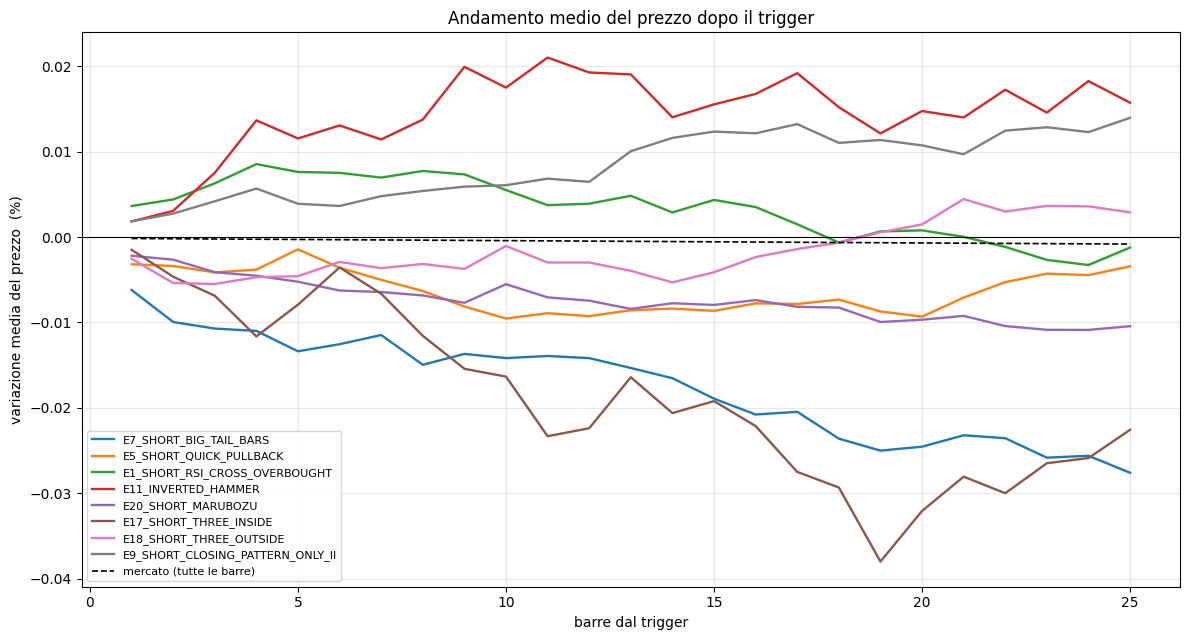

In [9]:
entry_candidate = [n for n in eng.registry.list_entries()]
ev = eng.event_study.run_event_study(df_is, entry_names=entry_candidate, horizon=H, min_trades=MIN_TRADES)
ev.plot()

#### LONG side

In [10]:
l1 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
l1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
3,E11_INVERTED_HAMMER,2.313125,0.021008,2.701351,False
10,E1_RSI_CROSS_OVERSOLD,1.732702,0.015706,1.972294,False
26,E7_BIG_TAIL_BARS,1.276890,0.011531,1.288670,False
24,E18_THREE_OUTSIDE,1.166336,0.010629,1.385477,False
32,E6_BACK_IN_STYLE,0.860244,0.007782,1.110424,False
28,E14_HARAMI_CROSS,0.841387,0.007599,1.193692,False


In [11]:
l2 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)
l2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
5,E17_SHORT_THREE_INSIDE,-4.177133,-0.037976,-2.372705,False
0,E7_SHORT_BIG_TAIL_BARS,-3.047526,-0.027587,-2.987233,False
21,E16_SHORT_EVENING_STAR,-1.655397,-0.015022,-1.471398,False
18,E6_SHORT_BACK_IN_STYLE,-1.486623,-0.013440,-1.650280,False
4,E20_SHORT_MARUBOZU,-1.203756,-0.010870,-2.487167,False
45,E11_SHORT_SHOOTING_STAR_CONFIRMED,-1.153776,-0.010473,-0.727566,False


#### SHORT side

In [12]:
s1 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
s1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
7,E9_SHORT_CLOSING_PATTERN_ONLY_II,1.543825,0.013950,2.258658,False
27,E4_SHORT_EMA_CROSS_DOWN,1.082217,0.009793,1.237565,False
2,E1_SHORT_RSI_CROSS_OVERBOUGHT,0.946055,0.008538,2.783721,False
12,E3_SHORT_INTRABAR_STRENGTH_FADE,0.410163,0.003706,1.870053,False
46,E10_SHORT_HANGING_MAN,0.309685,0.002793,0.633767,False
14,E2_SHORT_ZLEMA_CROSS_DOWN,-0.210925,-0.001906,-1.809164,False


In [13]:
s2 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)

s2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
22,E17_THREE_INSIDE,-1.944269,-0.017650,-1.466669,False
8,E4_EMA_CROSS_UP,-1.462301,-0.013231,-2.232531,False
47,E16_MORNING_STAR,-1.074913,-0.009789,-0.525162,False
9,E5_QUICK_PULLBACK,-0.958929,-0.008670,-2.015190,False
34,E14_HARAMI_CROSS_CONFIRMED,-0.853003,-0.007694,-1.076027,False
19,E8_CLOSING_PATTERN_ONLY,-0.568189,-0.005132,-1.592568,False


### LONG Dataframe

In [14]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_long_selected_feat  = l1.iloc[:2,0].to_list() + s1.iloc[:2,0].to_list()

df_LONG = df[colonne_ohlcv + entry_long_selected_feat + colonne_eventi]
df_LONG

,Open,High,Low,Close,Volume,E11_INVERTED_HAMMER,E1_RSI_CROSS_OVERSOLD,E9_SHORT_CLOSING_PATTERN_ONLY_II,E4_SHORT_EMA_CROSS_DOWN,F1_ADX_ABOVE,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-03 19:00:00+00:00,1.10614,1.10630,1.10614,1.10622,274,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2020-02-03 19:15:00+00:00,1.10622,1.10634,1.10612,1.10634,175,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2020-02-03 19:30:00+00:00,1.10634,1.10646,1.10610,1.10640,209,False,False,False,False,False,...,True,False,True,False,True,False,False,True,True,False
2020-02-03 19:45:00+00:00,1.10640,1.10654,1.10616,1.10635,387,False,False,False,False,False,...,False,True,True,False,True,False,False,True,True,False
2020-02-03 20:00:00+00:00,1.10635,1.10640,1.10610,1.10614,251,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,False,False,False,False,True,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,False,False,False,False,True,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,False,False,False,False,True,...,True,False,True,False,False,False,True,False,True,False


#### SHORT Dataframe

In [15]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_short_selected_feat = l2.iloc[:2,0].to_list() + s2.iloc[:2,0].to_list()

df_SHORT = df[colonne_ohlcv + entry_short_selected_feat + colonne_eventi]
df_SHORT

,Open,High,Low,Close,Volume,E17_SHORT_THREE_INSIDE,E7_SHORT_BIG_TAIL_BARS,E17_THREE_INSIDE,E4_EMA_CROSS_UP,F1_ADX_ABOVE,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-03 19:00:00+00:00,1.10614,1.10630,1.10614,1.10622,274,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2020-02-03 19:15:00+00:00,1.10622,1.10634,1.10612,1.10634,175,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2020-02-03 19:30:00+00:00,1.10634,1.10646,1.10610,1.10640,209,False,False,False,False,False,...,True,False,True,False,True,False,False,True,True,False
2020-02-03 19:45:00+00:00,1.10640,1.10654,1.10616,1.10635,387,False,False,False,False,False,...,False,True,True,False,True,False,False,True,True,False
2020-02-03 20:00:00+00:00,1.10635,1.10640,1.10610,1.10614,251,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,False,False,False,False,True,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,False,False,False,False,True,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,False,False,False,False,True,...,True,False,True,False,False,False,True,False,True,False


### Costruzione TARGET (LONG / SHORT)

Per ogni trigger calcola l'esito reale: ingresso all'Open della barra successiva, uscita al Close dopo H barre (stesso orizzonte dell'event study). TARGET=1 se il rendimento supera la soglia costi, 0 altrimenti. Righe senza trigger non compaiono — il modello vedrà solo occorrenze reali, mai "rumore".

**Come leggere l'output:** il numero di righe è quanti trigger sono utilizzabili per l'addestramento di ciascun lato; la % di classe 1 dice quanto è bilanciato il problema. Se una delle due % è vicina a 0% o 100%, il modello non ha nulla da imparare — fermati e segnalamelo prima di proseguire.

**Prossimo passo:** se i numeri sono ragionevoli, procediamo con lo split IS/OOS + embargo sui due target.

In [16]:
TARGET_LONG = costruisci_target(df_LONG, entry_long_selected_feat, direction=1, horizon=H)
TARGET_SHORT = costruisci_target(df_SHORT, entry_short_selected_feat, direction=-1, horizon=H)

print("LONG  — righe:", len(TARGET_LONG), " classe 1:", f"{TARGET_LONG.mean():.1%}")
print("SHORT — righe:", len(TARGET_SHORT), " classe 1:", f"{TARGET_SHORT.mean():.1%}")

LONG  — righe: 6790  classe 1: 48.5%
SHORT — righe: 3426  classe 1: 48.1%


### Split train/test e matrice X

Divide i trigger di df_is in train (80%, il passato) e test (20%, il periodo successivo). Toglie i trigger vicini ai confini la cui etichetta userebbe prezzi del test o dell'OOS. df_oos resta intatto.

**Come leggere l'output:** righe e % di classe 1 di train e test per ciascun lato; la % dovrebbe restare simile fra train e test. X deve avere 24 colonne (4 trigger + 20 contesto).


In [17]:
print("===== LONG =====")
idx_train_L, idx_test_L = split_train_test(TARGET_LONG, df_is, horizon=H, quota=0.8)
X_LONG = costruisci_X(df_LONG, TARGET_LONG, entry_long_selected_feat)

print("\n===== SHORT =====")
idx_train_S, idx_test_S = split_train_test(TARGET_SHORT, df_is, horizon=H, quota=0.8)
X_SHORT = costruisci_X(df_SHORT, TARGET_SHORT, entry_short_selected_feat)

===== LONG =====
confine train/test: 2024-04-30 22:30:00+00:00  (barra 105614 di 132018)
  trigger in OOS (non usati):       1325
  tolti dal purge (uscita in OOS):  2
  tolti dall'embargo (train->test): 1
  TRAIN:  4428 righe, classe 1 48.1%  (2020-02-04 -> 2024-04-30)
  TEST:   1034 righe, classe 1 49.0%  (2024-05-01 -> 2025-05-22)
X: 6790 righe x 24 colonne (4 trigger E* + 20 contesto F*)

===== SHORT =====
confine train/test: 2024-04-30 22:30:00+00:00  (barra 105614 di 132018)
  trigger in OOS (non usati):       673
  tolti dal purge (uscita in OOS):  0
  tolti dall'embargo (train->test): 0
  TRAIN:  2215 righe, classe 1 47.7%  (2020-02-04 -> 2024-04-30)
  TEST:    538 righe, classe 1 46.1%  (2024-05-01 -> 2025-05-22)
X: 3426 righe x 24 colonne (4 trigger E* + 20 contesto F*)


### Primo modello (LightGBM base, senza pesi) e valutazione

Addestra un modello per lato sul solo train e lo valuta sul test. Impostazioni prudenti, non ottimizzate: è la base di riferimento.

**Come leggere l'output:**
- **AUC**: 0,5 = ordine casuale. Se il train è molto sopra il test, il modello ha imparato regole valide solo sul train.
- **prob. train / test**: quanto sono larghe le probabilità. Se train e test sono molto diversi, qualcosa è cambiato fra i due periodi.
- **Tabella per fasce**: i trigger del test sono ordinati per probabilità e divisi in 5 gruppi uguali (1 = più bassa, 5 = più alta). Se vincenti % e bp crescono dalla 1 alla 5, l'ordine del modello contiene informazione. La riga "tutti" è il risultato senza modello. I bp sono lordi.
- **Feature più usate**: dove il modello cerca informazione.

#### LONG Side

In [18]:
REND_LONG = rendimenti_trigger(df_LONG, TARGET_LONG.index, direction=1, horizon=H)
modello_LONG = addestra(X_LONG, TARGET_LONG, idx_train_L, idx_test_L)

print("===== LONG =====")
fasce_LONG = valuta(modello_LONG, X_LONG, TARGET_LONG, REND_LONG, idx_train_L, idx_test_L)
print(fasce_LONG)
print("\nfeature piu' usate:")
print(importanza(modello_LONG, X_LONG).head(10))

===== LONG =====
AUC   train 0.610   test 0.516   (0.5 = ordine casuale)
prob. train: min 0.254  p10 0.402  p50 0.487  p90 0.552  max 0.758
prob. test:  min 0.254  p10 0.402  p50 0.487  p90 0.551  max 0.699
        prob_da  prob_a  trade  vincenti_%  bp_medi_lordi
fascia                                                   
1         0.254   0.429    207        47.3           1.18
2         0.429   0.474    207        47.3          -2.99
3         0.475   0.501    206        49.5           0.30
4         0.501   0.529    207        49.3          -1.69
5         0.529   0.699    207        51.7           1.96
tutti     0.254   0.699   1034        49.0          -0.25

feature piu' usate:
F10_TREND_CONVICTION_UP      8.9
F5_TALL_CANDLE               8.9
F11_TREND_CONVICTION_DOWN    8.1
F16_PRICE_ABOVE_VWAP         7.0
F1_ADX_ABOVE                 6.3
F2_MID_VOLATILITY            5.7
F3_VOLUME_ABOVE_AVG          5.7
E4_SHORT_EMA_CROSS_DOWN      4.8
F7_VOLUME_CLIMAX             4.2
F13_EXTENDE

#### SHORT Side

In [19]:
REND_SHORT = rendimenti_trigger(df_SHORT, TARGET_SHORT.index, direction=-1, horizon=H)
modello_SHORT = addestra(X_SHORT, TARGET_SHORT, idx_train_S, idx_test_S)

print("===== SHORT =====")
fasce_SHORT = valuta(modello_SHORT, X_SHORT, TARGET_SHORT, REND_SHORT, idx_train_S, idx_test_S)
print(fasce_SHORT)
print("\nfeature piu' usate:")
print(importanza(modello_SHORT, X_SHORT).head(10))

===== SHORT =====
AUC   train 0.665   test 0.497   (0.5 = ordine casuale)
prob. train: min 0.207  p10 0.354  p50 0.485  p90 0.581  max 0.738
prob. test:  min 0.205  p10 0.352  p50 0.478  p90 0.562  max 0.684
        prob_da  prob_a  trade  vincenti_%  bp_medi_lordi
fascia                                                   
1         0.205   0.396    108        46.3          -3.30
2         0.396   0.458    107        46.7          -3.04
3         0.459   0.497    108        42.6          -1.33
4         0.498   0.534    107        50.5           2.28
5         0.535   0.684    108        44.4           1.99
tutti     0.205   0.684    538        46.1          -0.68

feature piu' usate:
F5_TALL_CANDLE               15.1
F10_TREND_CONVICTION_UP      11.0
F2_MID_VOLATILITY            10.4
F2_HIGH_VOLATILITY            8.2
E7_SHORT_BIG_TAIL_BARS        6.3
F6_VOLUME_ABOVE_AVG_50        4.4
F11_TREND_CONVICTION_DOWN     4.4
F16_PRICE_ABOVE_VWAP          4.3
E17_SHORT_THREE_INSIDE        4.1
F

### Stesso modello con i pesi di unicità

I trigger ammassati (finestre di 25 barre sovrapposte) contano meno nell'addestramento: 5 trigger sulla stessa finestra valgono insieme circa quanto uno isolato. I pesi si calcolano solo sul train. La valutazione sul test è identica alla cella precedente.

**Come leggere l'output:** confronta AUC e tabella per fasce con quelli senza pesi. I pesi si tengono solo se migliorano il test.

In [20]:
PESI_LONG = pesi_unicita(idx_train_L, df_LONG, horizon=H)
modello_LONG_p = addestra(X_LONG, TARGET_LONG, idx_train_L, idx_test_L, pesi=PESI_LONG)
print("===== LONG con pesi =====")
print(f"pesi train: min {PESI_LONG.min():.2f}  mediana {PESI_LONG.median():.2f}  max {PESI_LONG.max():.2f}")
fasce_LONG_p = valuta(modello_LONG_p, X_LONG, TARGET_LONG, REND_LONG, idx_train_L, idx_test_L)
print(fasce_LONG_p)

PESI_SHORT = pesi_unicita(idx_train_S, df_SHORT, horizon=H)
modello_SHORT_p = addestra(X_SHORT, TARGET_SHORT, idx_train_S, idx_test_S, pesi=PESI_SHORT)
print("\n===== SHORT con pesi =====")
print(f"pesi train: min {PESI_SHORT.min():.2f}  mediana {PESI_SHORT.median():.2f}  max {PESI_SHORT.max():.2f}")
fasce_SHORT_p = valuta(modello_SHORT_p, X_SHORT, TARGET_SHORT, REND_SHORT, idx_train_S, idx_test_S)
print(fasce_SHORT_p)

===== LONG con pesi =====
pesi train: min 0.31  mediana 0.93  max 1.65
AUC   train 0.604   test 0.517   (0.5 = ordine casuale)
prob. train: min 0.192  p10 0.429  p50 0.516  p90 0.585  max 0.786
prob. test:  min 0.192  p10 0.432  p50 0.515  p90 0.581  max 0.770
        prob_da  prob_a  trade  vincenti_%  bp_medi_lordi
fascia                                                   
1         0.192   0.454    207        48.3           0.60
2         0.454   0.496    207        47.3          -1.64
3         0.496   0.531    206        43.7          -2.44
4         0.531   0.563    207        56.0           2.16
5         0.564   0.770    207        49.8           0.07
tutti     0.192   0.770   1034        49.0          -0.25

===== SHORT con pesi =====
pesi train: min 0.33  mediana 1.08  max 1.25
AUC   train 0.667   test 0.494   (0.5 = ordine casuale)
prob. train: min 0.176  p10 0.368  p50 0.486  p90 0.587  max 0.780
prob. test:  min 0.195  p10 0.363  p50 0.481  p90 0.573  max 0.741
        prob

### OOS — soglia fissata sul test, applicata tale e quale

Il modello è quello con i pesi, addestrato solo sul train. La soglia di probabilità è il limite inferiore della fascia scelta, calcolato solo sul test di df_is, e sull'OOS non si ricalcola niente.

FASCE_OPERATIVE = 5 prende il 20% più alto; (4, 5) prende il 40% più alto.

**Come leggere l'output:**
- **prob. test / OOS**: se le due distribuzioni sono simili, la soglia prende nell'OOS una quota simile a quella del test (~20% per la fascia 5).
- **tabella**: confronta "selezionati" con "tutti" nello stesso periodo. I bp sono lordi.

In [21]:
FASCE_OPERATIVE = 5          # oppure un intervallo, es. (4, 5)

idx_oos_L = indici_oos(TARGET_LONG, df_is)
print("===== LONG · OOS =====")
oos_LONG = valuta_oos(modello_LONG_p, X_LONG, TARGET_LONG, REND_LONG,
                      idx_test_L, idx_oos_L, fasce=FASCE_OPERATIVE)
print(oos_LONG)

idx_oos_S = indici_oos(TARGET_SHORT, df_is)
print("\n===== SHORT · OOS =====")
oos_SHORT = valuta_oos(modello_SHORT_p, X_SHORT, TARGET_SHORT, REND_SHORT,
                       idx_test_S, idx_oos_S, fasce=FASCE_OPERATIVE)
print(oos_SHORT)

===== LONG · OOS =====
fascia 5 di 5: soglia prob. da 0.563 a inf  (ricavata solo dal test)
prob. test: min 0.192  p10 0.432  p50 0.515  p90 0.581  max 0.770
prob. OOS : min 0.240  p10 0.438  p50 0.517  p90 0.586  max 0.714
OOS: 2025-05-25 22:15:00+00:00 -> 2026-09-18 11:15:00+00:00
               trade  presi_%  vincenti_%  bp_medi_lordi
                                                        
test fascia 5    207     20.0        49.8           0.07
test tutti      1034    100.0        49.0          -0.25
OOS fascia 5     300     22.6        53.3           1.83
OOS tutti       1325    100.0        49.1           0.83

===== SHORT · OOS =====
fascia 5 di 5: soglia prob. da 0.530 a inf  (ricavata solo dal test)
prob. test: min 0.195  p10 0.363  p50 0.481  p90 0.573  max 0.741
prob. OOS : min 0.230  p10 0.382  p50 0.483  p90 0.574  max 0.760
OOS: 2025-05-23 01:30:00+00:00 -> 2026-09-18 01:30:00+00:00
               trade  presi_%  vincenti_%  bp_medi_lordi
                               

### Backtest OOS (VectorBT)

Stesse regole del target:
- ingresso all'Open della barra successiva al trigger, uscita al Close a 25 barre, niente SL/TP;
- un trade alla volta per lato: i trigger che scattano con una posizione aperta si saltano (colonna "saltati");
- lotto fisso, commissione inclusa, spread escluso.

"tutti i trigger" = stesse regole senza modello, nello stesso periodo. VectorBT non gestisce il margine: il capitale deve coprire il controvalore di 1 lotto.

**Come leggere l'output:** confronta la riga del modello con "tutti i trigger" per ogni lato. Nel grafico, linea blu = modello, grigia = tutti. PnL nella valuta di quotazione (USD su EURUSD).

                               trade  saltati  vincenti_%  trade_medio_bp  \
lato      scenario                                                          
LONG      modello (fascia 5)   227.0     73.0       49.78            0.32   
SHORT     modello (fascia 5)   143.0      7.0       46.85           -1.82   
COMBINATO modello (fascia 5)   370.0     80.0       48.65           -0.51   
LONG      tutti i trigger      653.0    672.0       46.71           -0.44   
SHORT     tutti i trigger      462.0    211.0       52.38            0.10   
COMBINATO tutti i trigger     1115.0    883.0       49.06           -0.21   

                              profit_factor  pnl_totale  rendimento_%  \
lato      scenario                                                      
LONG      modello (fascia 5)           1.04      786.32          0.52   
SHORT     modello (fascia 5)           0.78    -3004.60         -2.00   
COMBINATO modello (fascia 5)           0.93    -2218.28         -1.48   
LONG      tutti i 

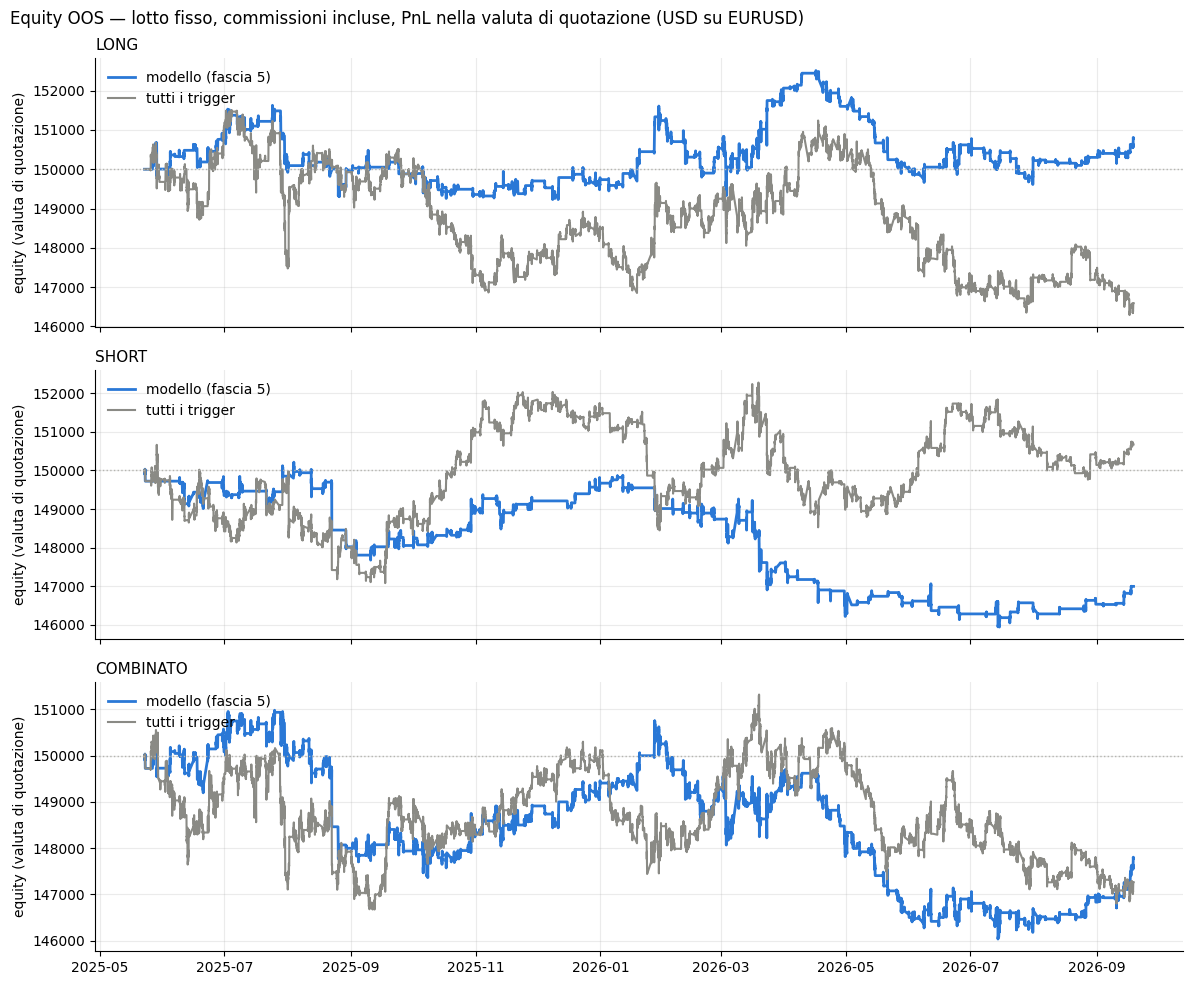

In [22]:
UNITA    = 100_000      # 1 lotto
CAPITALE = 150_000      # deve coprire il controvalore di UNITA
COSTO_RT = 0.65e-4      # commissione round-turn (da cambiare se cambi symbol)

df_periodo_oos = df.loc[df.index > df_is.index[-1]]

sel_L = trigger_in_fascia(modello_LONG_p, X_LONG, idx_test_L, idx_oos_L, fasce=FASCE_OPERATIVE)
sel_S = trigger_in_fascia(modello_SHORT_p, X_SHORT, idx_test_S, idx_oos_S, fasce=FASCE_OPERATIVE)

bt_modello = esegui_backtest(df_periodo_oos, sel_L, sel_S, H, UNITA, CAPITALE, COSTO_RT)
bt_tutti   = esegui_backtest(df_periodo_oos, idx_oos_L, idx_oos_S, H, UNITA, CAPITALE, COSTO_RT)

scenari = {f"modello (fascia {FASCE_OPERATIVE})": bt_modello, "tutti i trigger": bt_tutti}
print(tabella_metriche(scenari))
grafico_equity(scenari, CAPITALE);